# WeatherMesh-3 - Exploring the dataset
WindBorne WeatherMesh-3 (arXiv:2503.22235)

## Setup

In [5]:
import json
import glob
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import matplotlib.pyplot as plt


def find_repo():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "huge").is_dir() and (base / "constants").is_dir():
            return base
    return Path.cwd()


REPO = find_repo()
DATA_ROOT = REPO / "huge" / "proc" / "haoxing_data" / "wm3" / "data"
CONSTANTS = REPO / "constants"

print("repo:", REPO)
print("data root:", DATA_ROOT)
print("exists:", DATA_ROOT.is_dir())

repo: /Users/sudhanva/Desktop/WindBorne/WeatherMesh-3
data root: /Users/sudhanva/Desktop/WindBorne/WeatherMesh-3/huge/proc/haoxing_data/wm3/data
exists: True


## Variables, levels and grid
Pressure variables are ECMWF param ids. Each input source stores 5 pressure variables on its native set of levels, 4 core surface variables, and a handful of extra surface variables in separate files.

In [6]:
PRESSURE_VARS = ["129_z", "130_t", "131_u", "132_v", "133_q"]
SFC_VARS = ["165_10u", "166_10v", "167_2t", "151_msl"]
EXTRA_VARS = ["45_tcc", "168_2d", "246_100u", "247_100v"]

NAMES = {
    "129_z": "geopotential",
    "130_t": "temperature",
    "131_u": "u wind",
    "132_v": "v wind",
    "133_q": "specific humidity",
    "165_10u": "10m u wind",
    "166_10v": "10m v wind",
    "167_2t": "2m temperature",
    "151_msl": "mean sea level pressure",
    "45_tcc": "total cloud cover",
    "168_2d": "2m dewpoint",
    "246_100u": "100m u wind",
    "247_100v": "100m v wind",
}
UNITS = {
    "129_z": "m^2/s^2",
    "130_t": "K",
    "131_u": "m/s",
    "132_v": "m/s",
    "133_q": "kg/kg",
    "165_10u": "m/s",
    "166_10v": "m/s",
    "167_2t": "K",
    "151_msl": "Pa",
    "45_tcc": "fraction",
    "168_2d": "K",
    "246_100u": "m/s",
    "247_100v": "m/s",
}

LEVELS_GFS = [10, 30, 50, 70, 100, 150, 200, 250, 300, 350, 400, 450, 500,
              550, 600, 650, 700, 750, 800, 850, 900, 925, 950, 975, 1000]
LEVELS_HRES = [10, 20, 30, 50, 70, 100, 150, 200, 250, 300, 400, 500, 600,
               700, 800, 850, 900, 925, 950, 1000]
LEVELS_FULL = [1, 2, 3, 5, 7, 10, 20, 30, 50, 70, 100, 125, 150, 175, 200,
               225, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750,
               775, 800, 825, 850, 875, 900, 925, 950, 975, 1000]

SOURCE_LEVELS = {"neogfs": LEVELS_GFS, "neohres": LEVELS_HRES}

RES = 0.25
LATS = np.arange(90, -90.01, -RES)
LONS = np.arange(0, 360, RES)

print("grid:", len(LATS), "lats x", len(LONS), "lons at", RES, "deg")
print("gfs levels:", len(LEVELS_GFS), "  hres levels:", len(LEVELS_HRES))

grid: 721 lats x 1440 lons at 0.25 deg
gfs levels: 25   hres levels: 20


## File inventory
Walk the tree, decode each unix-timestamp filename to a UTC datetime, and report the array shapes held in every `.npz`.

In [7]:
def decode_ts(stem):
    return datetime.fromtimestamp(int(stem), tz=timezone.utc)


rows = []
for path in sorted(DATA_ROOT.glob("**/*.npz")):
    rel = path.relative_to(DATA_ROOT).parts
    source = rel[0]
    if rel[1] == "extra":
        kind = f"extra/{rel[2]}"
        month = rel[3]
    else:
        kind = rel[1]
        month = rel[2]
    ts = path.stem
    with np.load(path) as z:
        shapes = "  ".join(f"{k}{z[k].shape}" for k in z.files)
        dtypes = ",".join(sorted({str(z[k].dtype) for k in z.files}))
    rows.append((source, kind, month, ts, decode_ts(ts).strftime("%Y-%m-%d %H:%MZ"),
                 f"{path.stat().st_size/1e6:.2f} MB", dtypes, shapes))

header = ("source", "kind", "month", "unix", "utc", "size", "dtype", "arrays")
widths = [max(len(str(r[i])) for r in rows + [header]) for i in range(len(header))]
line = "  ".join(str(header[i]).ljust(widths[i]) for i in range(len(header)))
print(line)
print("-" * len(line))
for r in rows:
    print("  ".join(str(r[i]).ljust(widths[i]) for i in range(len(header))))

source   kind            month   unix        utc                size       dtype    arrays                                 
---------------------------------------------------------------------------------------------------------------------------
neogfs   extra/168_2d    202503  1741305600  2025-03-07 00:00Z  2.08 MB    float16  x(721, 1440)                           
neogfs   extra/246_100u  202503  1741305600  2025-03-07 00:00Z  2.08 MB    float16  x(721, 1440)                           
neogfs   extra/247_100v  202503  1741305600  2025-03-07 00:00Z  2.08 MB    float16  x(721, 1440)                           
neogfs   extra/45_tcc    202503  1741305600  2025-03-07 00:00Z  2.08 MB    float16  x(721, 1440)                           
neogfs   f000            202503  1741305600  2025-03-07 00:00Z  267.87 MB  float16  pr(721, 1440, 5, 25)  sfc(721, 1440, 4)
neohres  extra/168_2d    202503  1741305600  2025-03-07 00:00Z  2.08 MB    float16  x(721, 1440)                           
neohres 

## Anatomy of one `f000` sample
`f000` is the analysis (forecast hour 0). It holds a `pr` tensor `(lat, lon, variable, level)` and an `sfc` tensor `(lat, lon, variable)`.

In [8]:
def f000_path(source):
    return sorted((DATA_ROOT / source / "f000").glob("**/*.npz"))[0]


def extra_path(source, var):
    return sorted((DATA_ROOT / source / "extra" / var).glob("**/*.npz"))[0]


gfs = np.load(f000_path("neogfs"))
pr, sfc = gfs["pr"], gfs["sfc"]

print("neogfs f000:", f000_path("neogfs").name,
      "->", decode_ts(f000_path("neogfs").stem).strftime("%Y-%m-%d %H:%MZ"))
print()
print("pr ", pr.shape, pr.dtype, "  = (lat, lon,", len(PRESSURE_VARS), "vars,",
      len(LEVELS_GFS), "levels)")
print("sfc", sfc.shape, sfc.dtype, "  = (lat, lon,", len(SFC_VARS), "vars)")
print()
for i, v in enumerate(PRESSURE_VARS):
    a = pr[..., i, :].astype(np.float32)
    print(f"  pr  {v:9} {NAMES[v]:22} normed min {a.min():7.2f}  max {a.max():7.2f}")
for i, v in enumerate(SFC_VARS):
    a = sfc[..., i].astype(np.float32)
    print(f"  sfc {v:9} {NAMES[v]:22} normed min {a.min():7.2f}  max {a.max():7.2f}")

neogfs f000: 1741305600.npz -> 2025-03-07 00:00Z

pr  (721, 1440, 5, 25) float16   = (lat, lon, 5 vars, 25 levels)
sfc (721, 1440, 4) float16   = (lat, lon, 4 vars)

  pr  129_z     geopotential           normed min   -4.58  max    4.79
  pr  130_t     temperature            normed min   -4.98  max    8.58
  pr  131_u     u wind                 normed min   -4.32  max    4.92
  pr  132_v     v wind                 normed min   -8.11  max   10.54
  pr  133_q     specific humidity      normed min  -12.61  max    5.80
  sfc 165_10u   10m u wind             normed min   -4.02  max    3.97
  sfc 166_10v   10m v wind             normed min   -5.00  max    4.92
  sfc 167_2t    2m temperature         normed min   -4.89  max    1.50
  sfc 151_msl   mean sea level pressure normed min   -4.55  max    5.26


## Normalization and de-normalization
Every stored value is z-scored: `stored = (raw - mean) / std`. The per-variable (and per-level, for pressure fields) statistics live in `constants/normalization.json`. Invert them to recover physical units.

In [9]:
NORM = json.load(open(CONSTANTS / "normalization.json"))


def denorm_pr(pr_array, var, levels):
    vi = PRESSURE_VARS.index(var)
    mean = np.array(NORM[var]["mean"])
    std = np.array(NORM[var]["std"])
    out = np.empty(pr_array.shape[:2] + (len(levels),), np.float32)
    for j, lv in enumerate(levels):
        k = LEVELS_FULL.index(lv)
        out[..., j] = pr_array[..., vi, j].astype(np.float32) * std[k] + mean[k]
    return out


def denorm_sfc(sfc_array, var):
    vi = SFC_VARS.index(var)
    return sfc_array[..., vi].astype(np.float32) * NORM[var]["std"] + NORM[var]["mean"]


def denorm_extra(x, var):
    return x.astype(np.float32) * NORM[var]["std"] + NORM[var]["mean"]


t2m = denorm_sfc(sfc, "167_2t")
z500 = denorm_pr(pr, "129_z", LEVELS_GFS)[..., LEVELS_GFS.index(500)] / 9.80665
print(f"2m temperature: {t2m.min()-273.15:6.1f} .. {t2m.max()-273.15:6.1f} degC")
print(f"500 hPa geopotential height: {z500.min():6.0f} .. {z500.max():6.0f} m")

2m temperature:  -60.9 ..   37.5 degC
500 hPa geopotential height:   4774 ..   5982 m


## Surface fields

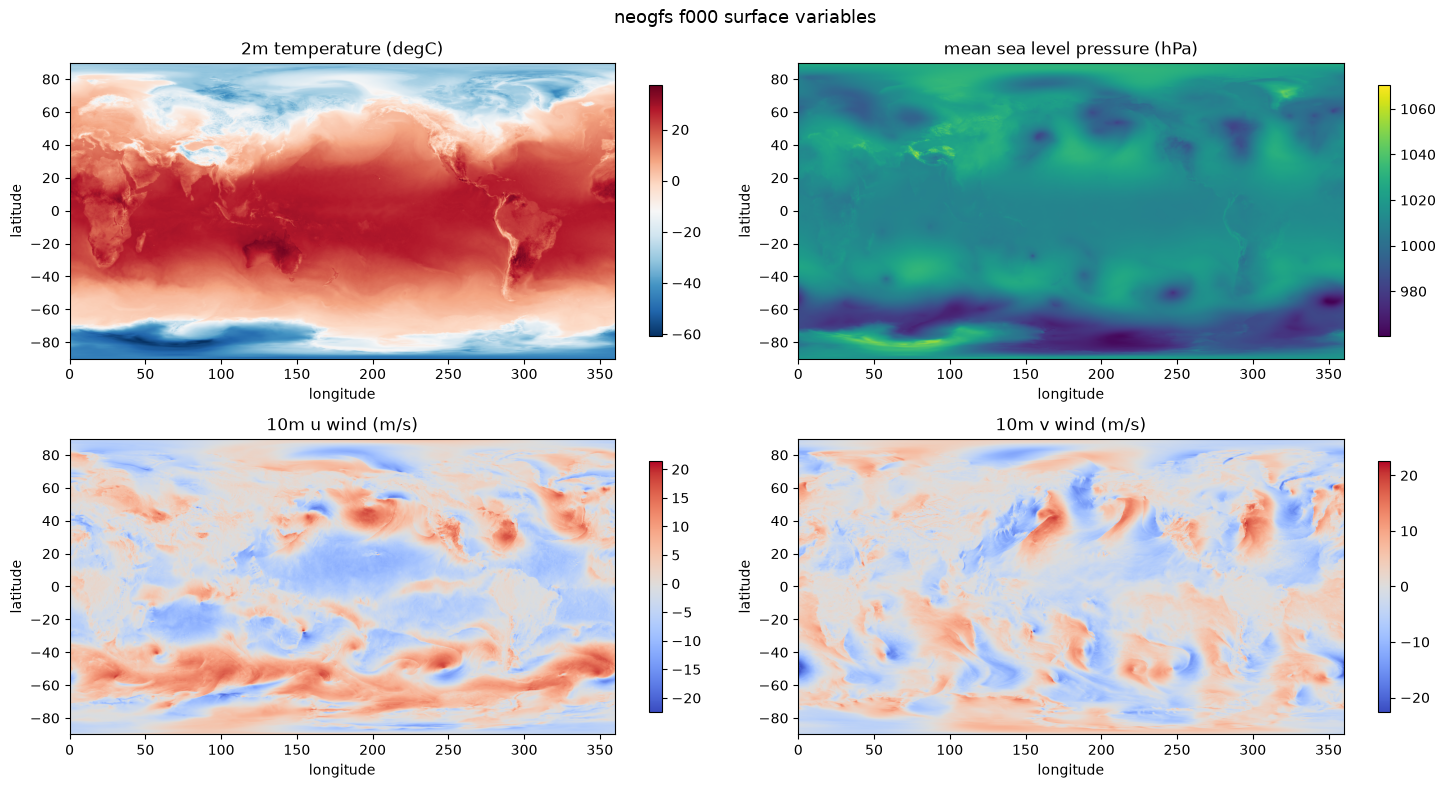

In [10]:
LAT_EXT = [0, 360, -90, 90]


def show_map(field, title, cmap="viridis", ax=None):
    ax = ax or plt.gca()
    im = ax.imshow(np.asarray(field, np.float32), extent=LAT_EXT,
                   origin="upper", aspect="auto", cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    plt.colorbar(im, ax=ax, shrink=0.85)


fig, axes = plt.subplots(2, 2, figsize=(15, 8))
show_map(denorm_sfc(sfc, "167_2t") - 273.15, "2m temperature (degC)", "RdBu_r", axes[0, 0])
show_map(denorm_sfc(sfc, "151_msl") / 100, "mean sea level pressure (hPa)", "viridis", axes[0, 1])
show_map(denorm_sfc(sfc, "165_10u"), "10m u wind (m/s)", "coolwarm", axes[1, 0])
show_map(denorm_sfc(sfc, "166_10v"), "10m v wind (m/s)", "coolwarm", axes[1, 1])
fig.suptitle("neogfs f000 surface variables", fontsize=13)
fig.tight_layout()
plt.show()

## Extra surface fields
Stored one variable per file under `extra/`, each an `x` array of shape `(lat, lon)`.

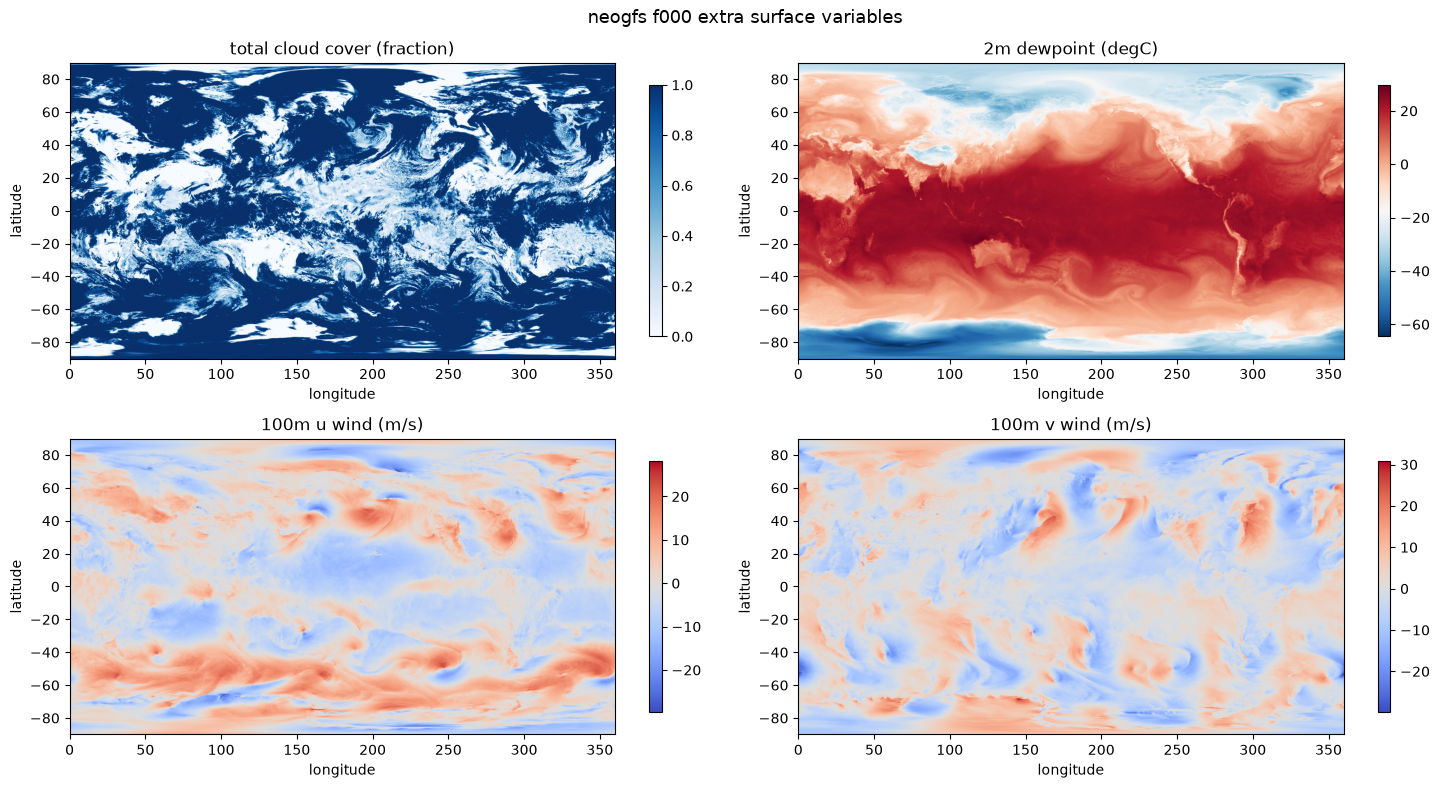

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
tcc = np.load(extra_path("neogfs", "45_tcc"))["x"].astype(np.float32)
d2m = denorm_extra(np.load(extra_path("neogfs", "168_2d"))["x"], "168_2d") - 273.15
u100 = denorm_extra(np.load(extra_path("neogfs", "246_100u"))["x"], "246_100u")
v100 = denorm_extra(np.load(extra_path("neogfs", "247_100v"))["x"], "247_100v")
show_map(tcc, "total cloud cover (fraction)", "Blues", axes[0, 0])
show_map(d2m, "2m dewpoint (degC)", "RdBu_r", axes[0, 1])
show_map(u100, "100m u wind (m/s)", "coolwarm", axes[1, 0])
show_map(v100, "100m v wind (m/s)", "coolwarm", axes[1, 1])
fig.suptitle("neogfs f000 extra surface variables", fontsize=13)
fig.tight_layout()
plt.show()

## A pressure-level field: 500 hPa geopotential height

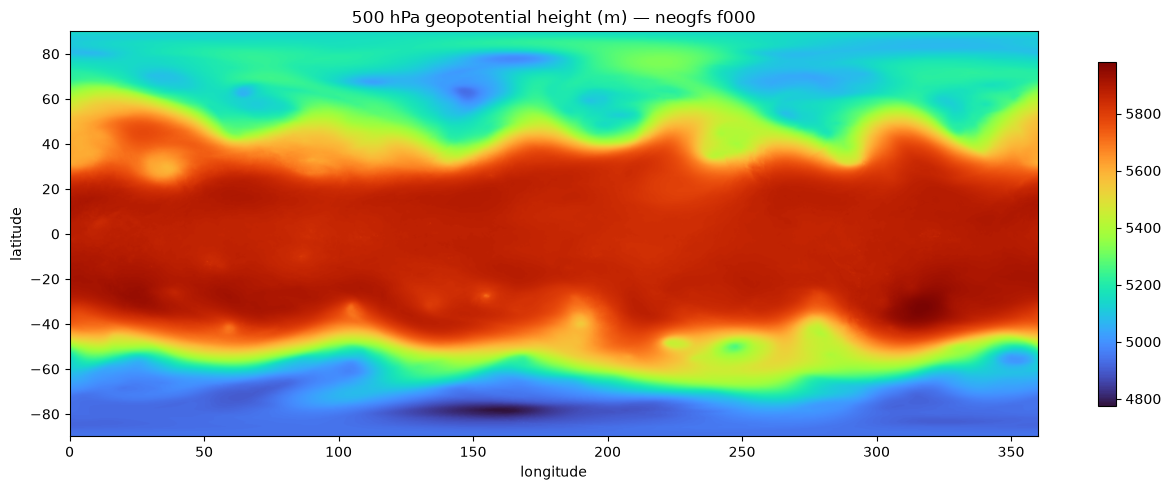

In [12]:
plt.figure(figsize=(13, 5))
show_map(z500, "500 hPa geopotential height (m) — neogfs f000", "turbo")
plt.tight_layout()
plt.show()

## GFS vs HRES
The two input sources cover the same grid and timestamp but differ in vertical resolution (25 vs 20 levels). Compare 500 hPa temperature and their difference.

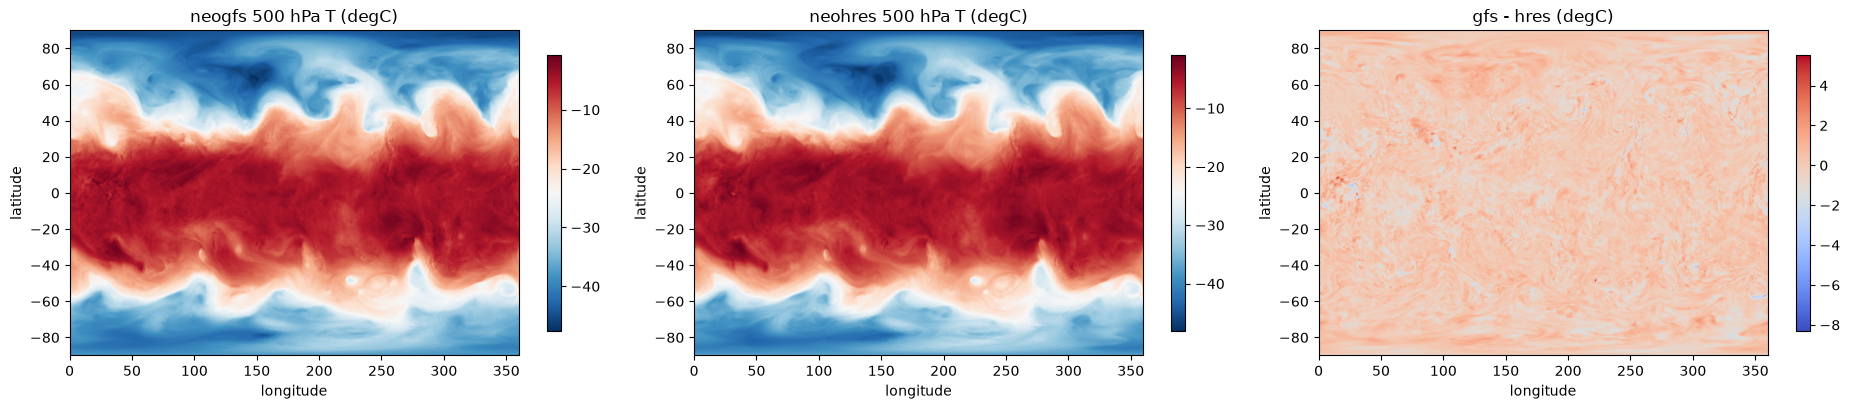

mean abs diff at 500 hPa: 0.41759208 degC


In [13]:
hres = np.load(f000_path("neohres"))
pr_h = hres["pr"]

t500_g = denorm_pr(pr, "130_t", LEVELS_GFS)[..., LEVELS_GFS.index(500)] - 273.15
t500_h = denorm_pr(pr_h, "130_t", LEVELS_HRES)[..., LEVELS_HRES.index(500)] - 273.15

fig, axes = plt.subplots(1, 3, figsize=(19, 4.2))
show_map(t500_g, "neogfs 500 hPa T (degC)", "RdBu_r", axes[0])
show_map(t500_h, "neohres 500 hPa T (degC)", "RdBu_r", axes[1])
show_map(t500_g - t500_h, "gfs - hres (degC)", "coolwarm", axes[2])
fig.tight_layout()
plt.show()

print("mean abs diff at 500 hPa:", np.abs(t500_g - t500_h).mean(), "degC")

## Vertical profile
De-normalized temperature through the full column at a single grid point.

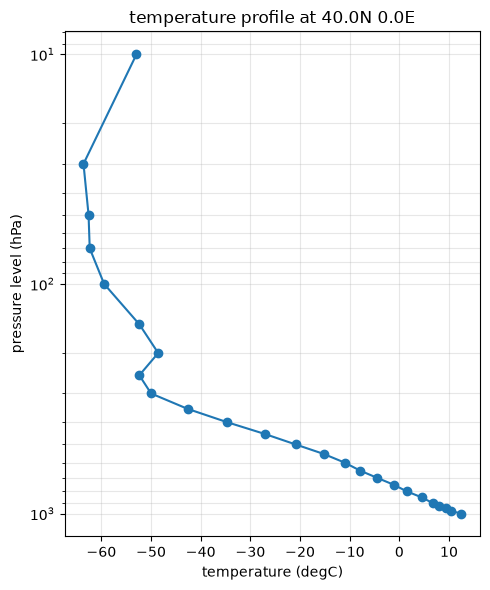

In [14]:
lat_deg, lon_deg = 40.0, 0.0
ilat = int(round((90 - lat_deg) / RES))
ilon = int(round((lon_deg % 360) / RES))

t_col = denorm_pr(pr, "130_t", LEVELS_GFS)[ilat, ilon] - 273.15

plt.figure(figsize=(5, 6))
plt.plot(t_col, LEVELS_GFS, marker="o")
plt.gca().invert_yaxis()
plt.yscale("log")
plt.xlabel("temperature (degC)")
plt.ylabel("pressure level (hPa)")
plt.title(f"temperature profile at {lat_deg}N {lon_deg}E")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## Value distributions
Because the data is z-scored, each pressure variable should sit close to a standard normal.

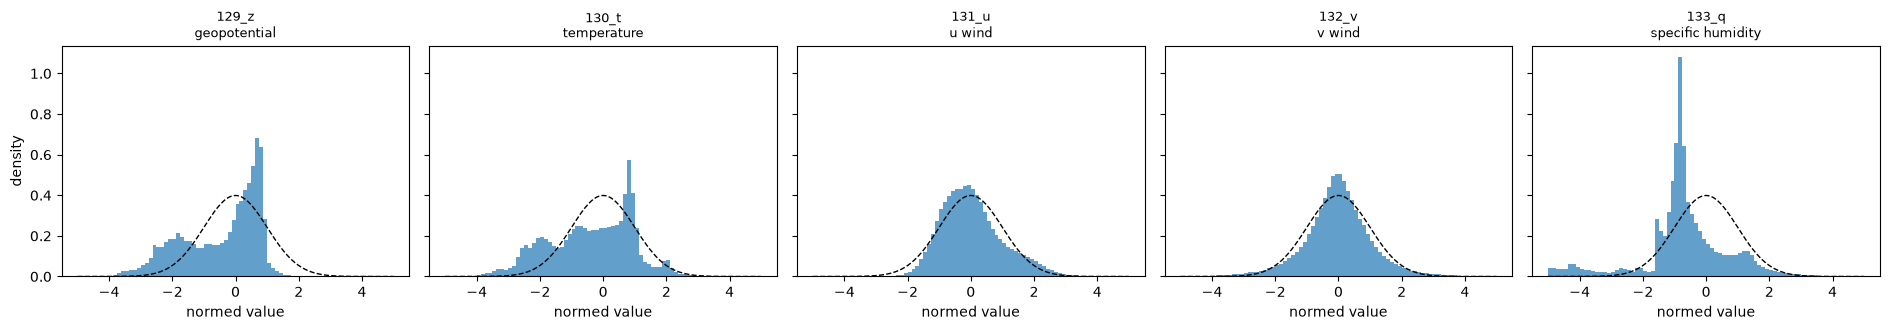

In [15]:
fig, axes = plt.subplots(1, len(PRESSURE_VARS), figsize=(19, 3.4), sharey=True)
xs = np.linspace(-5, 5, 200)
gauss = np.exp(-xs**2 / 2) / np.sqrt(2 * np.pi)
for ax, v in zip(axes, PRESSURE_VARS):
    vi = PRESSURE_VARS.index(v)
    sample = pr[::4, ::4, vi, :].astype(np.float32).ravel()
    ax.hist(sample, bins=80, range=(-5, 5), density=True, alpha=0.7)
    ax.plot(xs, gauss, "k--", lw=1)
    ax.set_title(f"{v}\n{NAMES[v]}", fontsize=9)
    ax.set_xlabel("normed value")
axes[0].set_ylabel("density")
fig.tight_layout()
plt.show()

## Summary

In [16]:
print("dataset root :", DATA_ROOT)
print("sources      :", ", ".join(sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir())))
print("grid         :", f"{len(LATS)} x {len(LONS)}", "at", RES, "deg")
print("samples      :", len(sorted(DATA_ROOT.glob('**/f000/**/*.npz'))), "f000 file(s)")
print()
for source, levels in SOURCE_LEVELS.items():
    p = f000_path(source)
    with np.load(p) as z:
        print(f"{source:9} f000  pr{z['pr'].shape}  sfc{z['sfc'].shape}"
              f"  levels={len(levels)}  time={decode_ts(p.stem).strftime('%Y-%m-%d %H:%MZ')}")
print()
print("extra surface vars:", ", ".join(f"{v} ({NAMES[v]})" for v in EXTRA_VARS))
print("all fields are float16 and z-scored; invert with constants/normalization.json")

dataset root : /Users/sudhanva/Desktop/WindBorne/WeatherMesh-3/huge/proc/haoxing_data/wm3/data
sources      : neogfs, neohres
grid         : 721 x 1440 at 0.25 deg
samples      : 2 f000 file(s)

neogfs    f000  pr(721, 1440, 5, 25)  sfc(721, 1440, 4)  levels=25  time=2025-03-07 00:00Z
neohres   f000  pr(721, 1440, 5, 20)  sfc(721, 1440, 4)  levels=20  time=2025-03-07 00:00Z

extra surface vars: 45_tcc (total cloud cover), 168_2d (2m dewpoint), 246_100u (100m u wind), 247_100v (100m v wind)
all fields are float16 and z-scored; invert with constants/normalization.json
